Dataset shape: (297, 15)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  num  heart_disease_present  
0  0.0   6.0    0                      0  
1  3.0   3.0    2                      1  
2  2.0   7.0    1                      1  
3  0.0   3.0    0                      0  
4  0.0   3.0    0                      0  

Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num',
       'heart_disease_present'],
      dtype='object')

Feature matrix shape: (297, 13)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8333,0.8462,0.7857,0.8148,0.9487
1,Random Forest,0.8500,0.8800,0.7857,0.8302,0.9408
2,Gradient Boosting,0.7667,0.7692,0.7143,0.7407,0.8828


Model comparison table saved as results/model_comparison_v2.csv

Dataset hash:
2126c12e0814c1d6452b2c1d55a9fbef1b02b17e2c84baf63d831bb036efeda9

Audit chain saved as results/audit_chain_v2.json
Total audit blocks created: 3

Audit chain summary:
Block Number: 1
Model Name: Logistic Regression
Model Version: v2_model_1
Previous Block Hash: 0
Current Block Hash: 6c2dd7a181fc3bf2b7b1600dfa4761d0ffc991ae20013a499be73303c039fc58
--------------------------------------------------------------------------------
Block Number: 2
Model Name: Random Forest
Model Version: v2_model_2
Previous Block Hash: 6c2dd7a181fc3bf2b7b1600dfa4761d0ffc991ae20013a499be73303c039fc58
Current Block Hash: a44d0a5c2ebfe66fc7cfbec1ab588560712bf9e053bd529ca84ac668379e27c0
--------------------------------------------------------------------------------
Block Number: 3
Model Name: Gradient Boosting
Model Version: v2_model_3
Previous Block Hash: a44d0a5c2ebfe66fc7cfbec1ab588560712bf9e053bd529ca84ac668379e27c0
Current Block

,Feature,Random Forest Importance,Gradient Boosting Importance,Average Importance
12,thal,0.121571,0.238263,0.179917
2,cp,0.142050,0.201355,0.171702
11,ca,0.097477,0.129729,0.113603
9,oldpeak,0.114585,0.089568,0.102076
0,age,0.094238,0.107332,0.100785
4,chol,0.089155,0.079743,0.084449
7,thalach,0.121296,0.040541,0.080918
3,trestbps,0.074891,0.043714,0.059303
10,slope,0.052333,0.032077,0.042205
8,exang,0.036495,0.011493,0.023994


Feature importance chart saved as results/feature_importance_v2.png


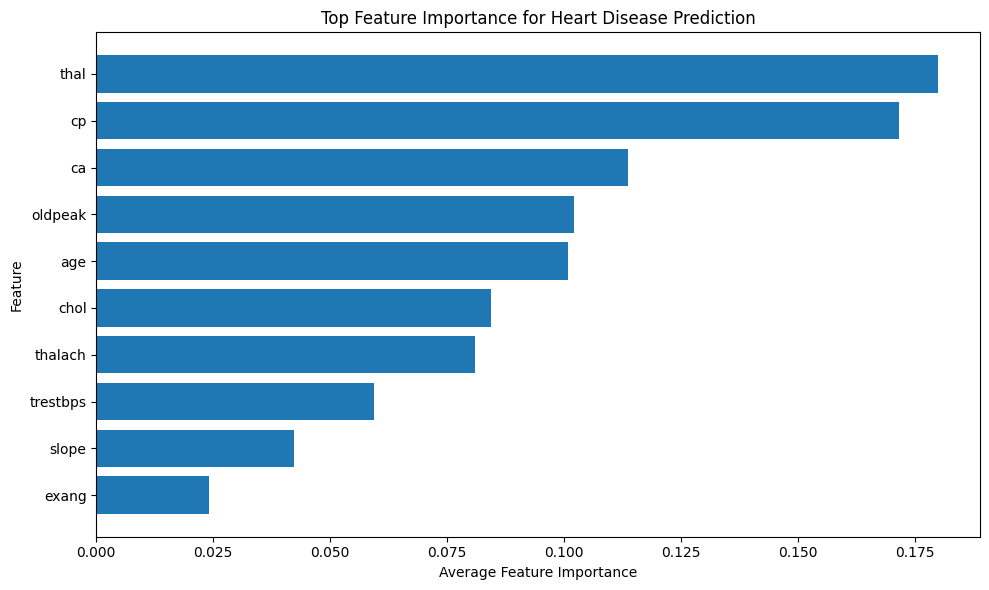


Final output check:
Created: results/model_comparison_v2.csv
Created: results/audit_chain_v2.json
Created: results/tamper_detection_results_v2.json
Created: results/feature_importance_v2.csv
Created: results/feature_importance_v2.png


In [1]:
# ============================================================
# Version 2: Model Comparison + Audit Chain + Tamper Detection
# Project: Designing a Blockchain-Inspired Audit Trail for
# Machine Learning Models Used in Heart Disease Risk Prediction
# ============================================================

# -----------------------------
# Step 1: Import libraries
# -----------------------------

import os
import json
import copy
import hashlib
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# -----------------------------
# Step 2: Create folders
# -----------------------------

os.makedirs("results", exist_ok=True)


# -----------------------------
# Step 3: Load cleaned dataset
# -----------------------------

url = "https://raw.githubusercontent.com/CurlyRivera/blockchain-audit-trail-heart-disease-ml/main/data/heart_disease_clean_v1.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print(df.head())
print("\nColumns:")
print(df.columns)


# -----------------------------
# Step 4: Separate features and target
# -----------------------------

# Features = all clinical predictor variables
X = df.drop(columns=["num", "heart_disease_present"])

# Target = binary heart disease outcome
y = df["heart_disease_present"]

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget class distribution:")
print(y.value_counts())


# -----------------------------
# Step 5: Train/test split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain/test split:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


# -----------------------------
# Step 6: Train multiple models
# -----------------------------

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    print(f"{model_name} trained successfully.")


# -----------------------------
# Step 7: Evaluate every model
# -----------------------------

model_results = []

for model_name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": float(accuracy_score(y_test, y_pred)),
        "Precision": float(precision_score(y_test, y_pred)),
        "Recall": float(recall_score(y_test, y_pred)),
        "F1 Score": float(f1_score(y_test, y_pred)),
        "ROC-AUC": float(roc_auc_score(y_test, y_prob))
    }

    model_results.append(results)

model_comparison_v2 = pd.DataFrame(model_results)

# Display rounded comparison table
print("\nModel comparison table:")
display(model_comparison_v2.round(4))

# Save model comparison table
model_comparison_v2.to_csv("results/model_comparison_v2.csv", index=False)

print("Model comparison table saved as results/model_comparison_v2.csv")


# -----------------------------
# Step 8: Hashing helper functions
# -----------------------------

# Save the cleaned dataset locally so it can be hashed
dataset_filename = "heart_disease_clean_v1.csv"
df.to_csv(dataset_filename, index=False)

def hash_file(filename):
    """Create a SHA-256 hash for a file."""
    sha256_hash = hashlib.sha256()
    with open(filename, "rb") as f:
        for byte_block in iter(lambda: f.read(4096), b""):
            sha256_hash.update(byte_block)
    return sha256_hash.hexdigest()

def hash_block(block):
    """Create a SHA-256 hash for an audit block."""
    block_string = json.dumps(block, sort_keys=True).encode()
    return hashlib.sha256(block_string).hexdigest()

dataset_hash = hash_file(dataset_filename)

print("\nDataset hash:")
print(dataset_hash)


# -----------------------------
# Step 9: Create audit chain
# -----------------------------

audit_chain_v2 = []
previous_block_hash = "0"

# Use one timestamp for the full Version 2 run
run_timestamp = datetime.now().isoformat()

# Convert class distribution into standard Python int values
class_distribution = {
    str(int(label)): int(count)
    for label, count in y.value_counts().to_dict().items()
}

for i, (model_name, model) in enumerate(trained_models.items(), start=1):

    model_metrics = model_comparison_v2[
        model_comparison_v2["Model"] == model_name
    ].iloc[0].to_dict()

    # Remove model name because it is recorded separately
    model_metrics.pop("Model")

    audit_block = {
        "block_number": i,
        "project_title": "Designing a Blockchain-Inspired Audit Trail for Machine Learning Models Used in Heart Disease Risk Prediction",
        "dataset_name": "UCI Heart Disease Dataset",
        "dataset_version": "heart_disease_clean_v1",
        "dataset_hash": dataset_hash,

        # Optional reproducibility fields
        "target_variable": "heart_disease_present",
        "class_distribution": class_distribution,
        "train_test_split": {
            "test_size": 0.2,
            "random_state": 42,
            "stratified": True
        },

        # Model information
        "model_name": model_name,
        "model_version": f"v2_model_{i}",
        "training_date": run_timestamp,
        "features_used": list(X.columns),
        "hyperparameters": model.get_params(),
        "performance_metrics": model_metrics,

        # Blockchain-inspired linking
        "previous_block_hash": previous_block_hash
    }

    audit_block["current_block_hash"] = hash_block(audit_block)

    audit_chain_v2.append(audit_block)

    previous_block_hash = audit_block["current_block_hash"]

# Save audit chain
with open("results/audit_chain_v2.json", "w") as f:
    json.dump(audit_chain_v2, f, indent=4)

print("\nAudit chain saved as results/audit_chain_v2.json")
print(f"Total audit blocks created: {len(audit_chain_v2)}")


# -----------------------------
# Step 10: Display audit chain summary
# -----------------------------

print("\nAudit chain summary:")

for block in audit_chain_v2:
    print("Block Number:", block["block_number"])
    print("Model Name:", block["model_name"])
    print("Model Version:", block["model_version"])
    print("Previous Block Hash:", block["previous_block_hash"])
    print("Current Block Hash:", block["current_block_hash"])
    print("-" * 80)


# -----------------------------
# Step 11: Tamper-detection testing
# -----------------------------

def recalculate_block_hash(block):
    """
    Recalculate a block hash after removing the saved current_block_hash.
    If the recalculated hash does not match the saved hash, the block was changed.
    """
    block_copy = copy.deepcopy(block)
    block_copy.pop("current_block_hash", None)
    return hash_block(block_copy)

def verify_audit_chain(chain):
    """Verify whether all blocks and chain links are valid."""
    verification_results = []
    chain_is_valid = True

    for i, block in enumerate(chain):
        saved_current_hash = block["current_block_hash"]
        recalculated_hash = recalculate_block_hash(block)

        hash_matches = saved_current_hash == recalculated_hash

        if i == 0:
            previous_hash_matches = block["previous_block_hash"] == "0"
        else:
            previous_hash_matches = block["previous_block_hash"] == chain[i - 1]["current_block_hash"]

        block_is_valid = hash_matches and previous_hash_matches

        if not block_is_valid:
            chain_is_valid = False

        verification_results.append({
            "block_number": block["block_number"],
            "model_name": block["model_name"],
            "saved_current_hash": saved_current_hash,
            "recalculated_hash": recalculated_hash,
            "hash_matches": hash_matches,
            "previous_hash_matches": previous_hash_matches,
            "block_is_valid": block_is_valid
        })

    return {
        "chain_is_valid": chain_is_valid,
        "verification_results": verification_results
    }

# Verify original chain
original_verification = verify_audit_chain(audit_chain_v2)

tamper_tests = {}

# Test 1: Change one performance metric
tampered_metric_chain = copy.deepcopy(audit_chain_v2)
tampered_metric_chain[0]["performance_metrics"]["Accuracy"] = 0.99
tamper_tests["tamper_metric_accuracy"] = verify_audit_chain(tampered_metric_chain)

# Test 2: Change the model name
tampered_model_name_chain = copy.deepcopy(audit_chain_v2)
tampered_model_name_chain[1]["model_name"] = "Tampered Random Forest"
tamper_tests["tamper_model_name"] = verify_audit_chain(tampered_model_name_chain)

# Test 3: Change the dataset hash
tampered_dataset_hash_chain = copy.deepcopy(audit_chain_v2)
tampered_dataset_hash_chain[2]["dataset_hash"] = "tampered_dataset_hash"
tamper_tests["tamper_dataset_hash"] = verify_audit_chain(tampered_dataset_hash_chain)

# Test 4: Change a previous block hash
tampered_previous_hash_chain = copy.deepcopy(audit_chain_v2)
tampered_previous_hash_chain[2]["previous_block_hash"] = "tampered_previous_block_hash"
tamper_tests["tamper_previous_block_hash"] = verify_audit_chain(tampered_previous_hash_chain)

tamper_detection_results_v2 = {
    "project_title": "Designing a Blockchain-Inspired Audit Trail for Machine Learning Models Used in Heart Disease Risk Prediction",
    "original_chain_verification": original_verification,
    "tamper_tests": tamper_tests
}

with open("results/tamper_detection_results_v2.json", "w") as f:
    json.dump(tamper_detection_results_v2, f, indent=4)

print("\nTamper detection results saved as results/tamper_detection_results_v2.json")
print("Original chain valid:", original_verification["chain_is_valid"])

for test_name, test_result in tamper_tests.items():
    print(test_name, "valid:", test_result["chain_is_valid"])


# -----------------------------
# Step 12: Feature importance / explainability
# -----------------------------

random_forest_model = trained_models["Random Forest"]
gradient_boosting_model = trained_models["Gradient Boosting"]

feature_importance_v2 = pd.DataFrame({
    "Feature": X.columns,
    "Random Forest Importance": random_forest_model.feature_importances_,
    "Gradient Boosting Importance": gradient_boosting_model.feature_importances_
})

feature_importance_v2["Average Importance"] = (
    feature_importance_v2["Random Forest Importance"] +
    feature_importance_v2["Gradient Boosting Importance"]
) / 2

feature_importance_v2 = feature_importance_v2.sort_values(
    by="Average Importance",
    ascending=False
)

feature_importance_v2.to_csv("results/feature_importance_v2.csv", index=False)

print("\nFeature importance results saved as results/feature_importance_v2.csv")

display(feature_importance_v2)


# -----------------------------
# Step 13: Feature importance chart
# -----------------------------

top_features = feature_importance_v2.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Average Importance"])
plt.xlabel("Average Feature Importance")
plt.ylabel("Feature")
plt.title("Top Feature Importance for Heart Disease Prediction")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("results/feature_importance_v2.png", dpi=300, bbox_inches="tight")

print("Feature importance chart saved as results/feature_importance_v2.png")

plt.show()


# -----------------------------
# Step 14: Final output check
# -----------------------------

expected_files = [
    "results/model_comparison_v2.csv",
    "results/audit_chain_v2.json",
    "results/tamper_detection_results_v2.json",
    "results/feature_importance_v2.csv",
    "results/feature_importance_v2.png"
]

print("\nFinal output check:")

for file in expected_files:
    if os.path.exists(file):
        print(f"Created: {file}")
    else:
        print(f"Missing: {file}")